# EDA Triagegeist - MIMIC-IV-ED-Demo

from https://physionet.org/content/mimic-iv-ed-demo/2.2/

metadata available at https://mimic.mit.edu/docs/iv/modules/ed/

## Index

- [Imports](#imports)
- [Load and Merge Data](#load-and-merge-data)
- [Data Preparation](#data-preparation)
- [Distributions by Variable Type](#distributions-by-variable-type)
- [Missing Data Matrix](#missing-data-matrix)
- [Correlation Matrix](#correlation-matrix)
- [KMeans Clustering (k=5)](#kmeans-clustering-k5)

## Imports

In [1]:
#%pip install pandas seaborn matplotlib

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

from scipy.stats import pearsonr, spearmanr


# Project root path (used for relative file access)
path_project = "C:/Users/giuli/Documents/GitHub/triagegeist/"

SEED = 42

## Load and Merge Data

In [3]:
# File paths
triage_file_path = r"01_Data_processing\mimic-iv-ed-demo-2.2\ed\triage.csv"
edstay_file_path = r"01_Data_processing\mimic-iv-ed-demo-2.2\ed\edstays.csv"

# Load CSVs
triage_df = pd.read_csv(path_project + triage_file_path)
edstay_df = pd.read_csv(path_project + edstay_file_path)

print("triage df shape:", triage_df.shape)
print("edstay df shape:", edstay_df.shape)

# Inner merge on shared keys
df_triage_edstay = pd.merge(triage_df, edstay_df, on=["stay_id", "subject_id"], how="inner")

#drop hadm_id, desposition, outtime (these are not available at triage time and would be data leakage)
df_triage_edstay.drop(columns=["hadm_id", "disposition", "outtime"], inplace=True)

print("merged df shape:", df_triage_edstay.shape)
df_triage_edstay.tail() #because head has a lot of missing values

triage df shape: (222, 11)
edstay df shape: (222, 9)
merged df shape: (222, 15)


,subject_id,stay_id,temperature,heartrate,resprate,o2sat,sbp,dbp,pain,acuity,chiefcomplaint,intime,gender,race,arrival_transport
217,10023239,36323598,97.7,111.0,15.0,100.0,133.0,79.0,3,3.0,"Dehydration, Nausea, Rash",2140-09-14 14:43:00,F,WHITE,WALK IN
218,10039708,32345277,98.4,106.0,18.0,95.0,131.0,76.0,5,3.0,"Abd pain, Transfer",2142-03-25 22:22:00,F,BLACK/AFRICAN AMERICAN,AMBULANCE
219,10012853,35933027,96.8,78.0,16.0,95.0,186.0,66.0,8,3.0,Abd pain,2176-10-06 00:32:00,F,BLACK/AFRICAN AMERICAN,WALK IN
220,10007795,34807453,98.6,108.0,18.0,95.0,143.0,61.0,7,3.0,"Abd pain, Back pain",2136-09-22 17:07:00,F,WHITE,AMBULANCE
221,10037928,35156583,97.8,75.0,16.0,95.0,159.0,60.0,6,3.0,Back pain,2183-08-03 19:27:00,F,HISPANIC/LATINO - CUBAN,AMBULANCE


In [4]:
# Overview: schema and summary statistics
df_triage_edstay.info()
df_triage_edstay.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 222 entries, 0 to 221
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   subject_id         222 non-null    int64  
 1   stay_id            222 non-null    int64  
 2   temperature        196 non-null    float64
 3   heartrate          198 non-null    float64
 4   resprate           199 non-null    float64
 5   o2sat              198 non-null    float64
 6   sbp                199 non-null    float64
 7   dbp                199 non-null    float64
 8   pain               201 non-null    object 
 9   acuity             207 non-null    float64
 10  chiefcomplaint     222 non-null    object 
 11  intime             222 non-null    object 
 12  gender             222 non-null    object 
 13  race               222 non-null    object 
 14  arrival_transport  222 non-null    object 
dtypes: float64(7), int64(2), object(6)
memory usage: 26.1+ KB


,subject_id,stay_id,temperature,heartrate,resprate,o2sat,sbp,dbp,acuity
count,2.220000e+02,2.220000e+02,196.000000,198.000000,199.000000,198.000000,199.000000,199.000000,207.000000
mean,1.001960e+07,3.533334e+07,97.785714,91.171717,18.135678,97.691919,136.949749,77.040201,2.367150
std,1.226325e+04,2.996074e+06,4.484172,18.894062,3.007849,2.700072,27.830248,59.266121,0.653952
min,1.000003e+07,3.009412e+07,36.500000,43.000000,14.000000,78.000000,70.000000,42.000000,1.000000
25%,1.001285e+07,3.254778e+07,97.600000,77.000000,16.000000,97.000000,116.500000,62.000000,2.000000
50%,1.001715e+07,3.546143e+07,98.100000,89.500000,18.000000,98.000000,136.000000,72.000000,2.000000
75%,1.002633e+07,3.810308e+07,98.500000,104.000000,18.000000,100.000000,154.500000,82.500000,3.000000
max,1.004002e+07,3.996872e+07,100.300000,157.000000,32.000000,100.000000,218.000000,879.000000,4.000000


## Data Preparation

1. separado de acordo com tipo q deveria ser
2. processado para type desejado

    2.1. para data foi escolhido o formato %Y-%m-%d %H:%M:%S

    2.2. temperatura convertida para Celsius (°C)

3. Foram excluidas variaveis que nao sao possiveis obter na entrada da emergencia como hora de saida e disposition (forma de saida ex: internacao, casa...)

In [5]:
# --- Column classification by expected dtype ---

id_columns = ["subject_id", "stay_id"]

categorical_columns = ["gender", "race", "arrival_transport"]

string_columns = ["chiefcomplaint"] # free-text chief complaint at triage (e.g., "chest pain", "shortness of breath", etc.)

datetime_columns = ["intime"] # ED arrival time 

continuous_columns = ["temperature"]

int_columns = [
    "resprate",
    "heartrate",
    "o2sat",
    "pain",
    "sbp",   # systolic blood pressure
    "dbp",   # diastolic blood pressure
]

target_column = ["acuity"] # target variable: 1 (most urgent) to 5 (least urgent) assigned by triage nurse based on initial assessment

In [6]:
# --- Apply dtype conversions ---

DATETIME_FMT = "%Y-%m-%d %H:%M:%S"  # 24-hour (military) format

# IDs & integers -> nullable integer
for col in id_columns + int_columns:
    df_triage_edstay[col] = (
        pd.to_numeric(df_triage_edstay[col], errors="coerce")
        .round()
        .astype("Int64")
    )

# Continuous -> float64
for col in continuous_columns:
    df_triage_edstay[col] = pd.to_numeric(df_triage_edstay[col], errors="coerce").astype("float64")

# Convert temperature from Fahrenheit to Celsius
if "temperature" in df_triage_edstay.columns:
    df_triage_edstay["temperature"] = ((df_triage_edstay["temperature"] - 32) * 5 / 9).round(2)

# Categorical
for col in categorical_columns:
    df_triage_edstay[col] = df_triage_edstay[col].astype("category")

# Free-text
for col in string_columns:
    df_triage_edstay[col] = df_triage_edstay[col].astype("string")

# Datetime (24h military format)
for col in datetime_columns:
    df_triage_edstay[col] = (
        pd.to_datetime(df_triage_edstay[col], format=DATETIME_FMT, errors="coerce")
        .dt.floor("s")
    )

# Keep backward-compatible alias
df = df_triage_edstay

# Preview datetime columns in military format
preview = df[datetime_columns].head(3).copy()
for col in datetime_columns:
    preview[col] = preview[col].dt.strftime(DATETIME_FMT)

print("Datetime preview (YYYY-MM-DD HH:MM:SS, 24h):")
print(preview)
print("\nTemperature preview in Celsius (°C):")
print(df["temperature"].head())
print("\nFinal dtypes:")
print(df.dtypes)

Datetime preview (YYYY-MM-DD HH:MM:SS, 24h):
                intime
0  2178-07-17 16:58:00
1  2143-03-22 01:19:00
2  2147-12-30 06:45:00

Temperature preview in Celsius (°C):
0   NaN
1   NaN
2   NaN
3   NaN
4   NaN
Name: temperature, dtype: float64

Final dtypes:
subject_id                    Int64
stay_id                       Int64
temperature                 float64
heartrate                     Int64
resprate                      Int64
o2sat                         Int64
sbp                           Int64
dbp                           Int64
pain                          Int64
acuity                      float64
chiefcomplaint       string[python]
intime               datetime64[ns]
gender                     category
race                       category
arrival_transport          category
dtype: object


In [7]:
df.describe()

,subject_id,stay_id,temperature,heartrate,resprate,o2sat,sbp,dbp,pain,acuity,intime
count,222.0,222.0,196.000000,198.0,199.0,198.0,199.0,199.0,189.0,207.000000,222
mean,10019597.536036,35333339.157658,36.547908,91.171717,18.135678,97.691919,136.949749,77.040201,4.21164,2.367150,2157-09-10 17:55:54.864865280
min,10000032.0,30094124.0,2.500000,43.0,14.0,78.0,70.0,42.0,0.0,1.000000,2112-09-17 18:46:00
25%,10012853.0,32547775.0,36.440000,77.0,16.0,97.0,116.5,62.0,0.0,2.000000,2142-05-15 16:41:44.999999488
50%,10017151.0,35461434.0,36.720000,89.5,18.0,98.0,136.0,72.0,4.0,2.000000,2150-03-08 17:20:00
75%,10026329.25,38103083.75,36.940000,104.0,18.0,100.0,154.5,82.5,8.0,3.000000,2177-11-24 14:14:00
max,10040025.0,39968716.0,37.940000,157.0,32.0,100.0,218.0,879.0,13.0,4.000000,2201-10-30 10:48:00
std,12263.246499,2996074.490922,2.491215,18.894062,3.007849,2.700072,27.830248,59.266121,4.210887,0.653952,NaN


## Distributions by Variable Type

TODO 
- [ ] resolver race 
- [ ] agrupar classes raras: ~~dispositions~~ and race 
- [x] acuity so tem 4 categorias como é criada - problema da demo o [metadata](https://mimic.mit.edu/docs/iv/modules/ed/triage/#acuity:~:text=of%200%2D10.-,acuity,or%20more%20resources%20(labs%2C%20EKG%2C%20x%2Drays%2C%20IV%20fluids%2C%20etc)%20with,-stable%20vital%20signs) fala q sao 5 baseado no EHI
- [ ] pensar num processamento separado pra tabela medrecon - medicamentos em uso ao chegar



Categorical columns: ['gender', 'race', 'arrival_transport']
Integer columns: ['resprate', 'heartrate', 'o2sat', 'pain', 'sbp', 'dbp', 'acuity']
Float columns: ['temperature']


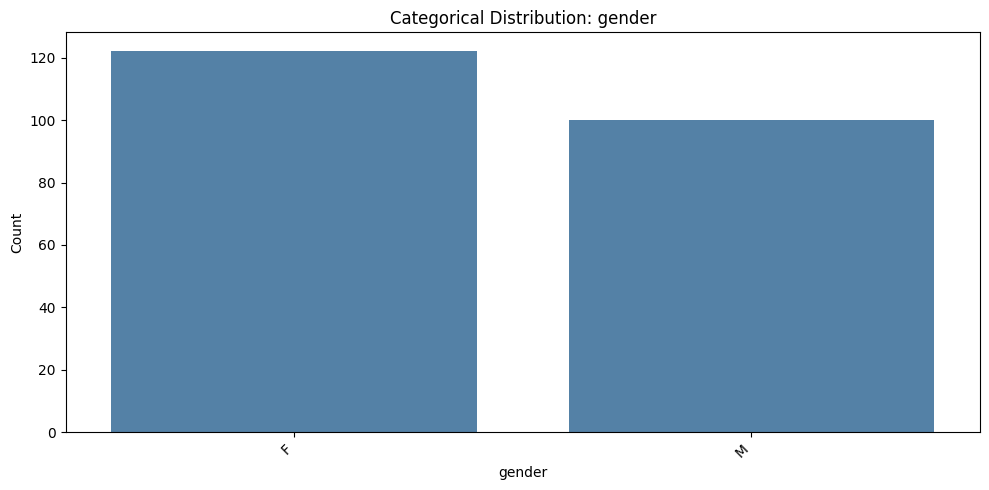

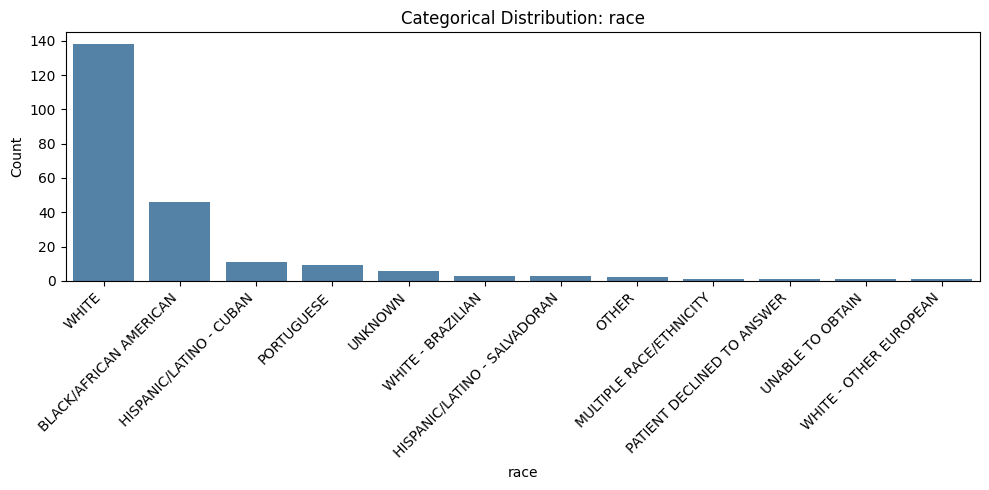

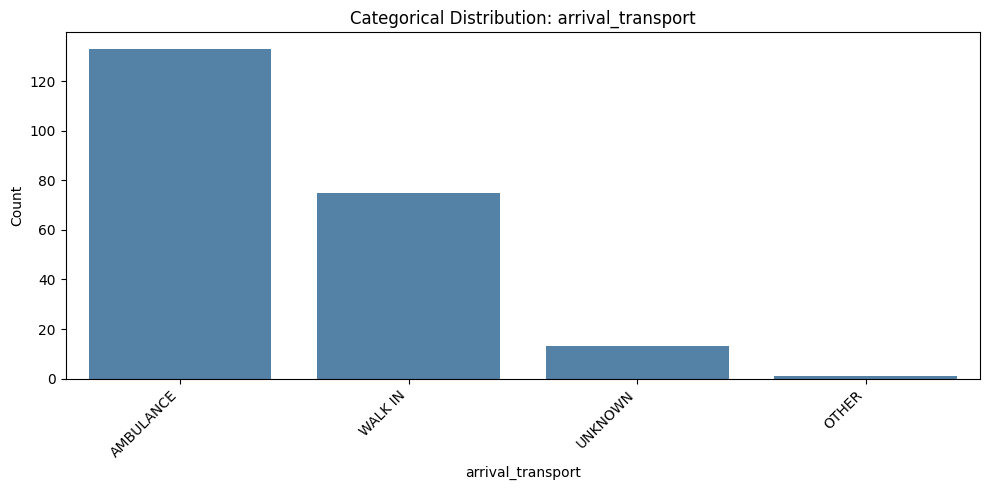

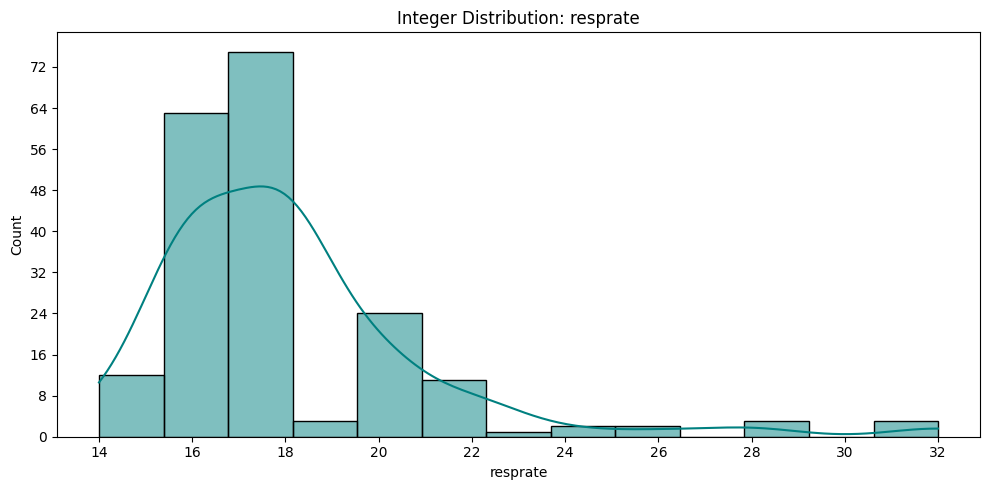

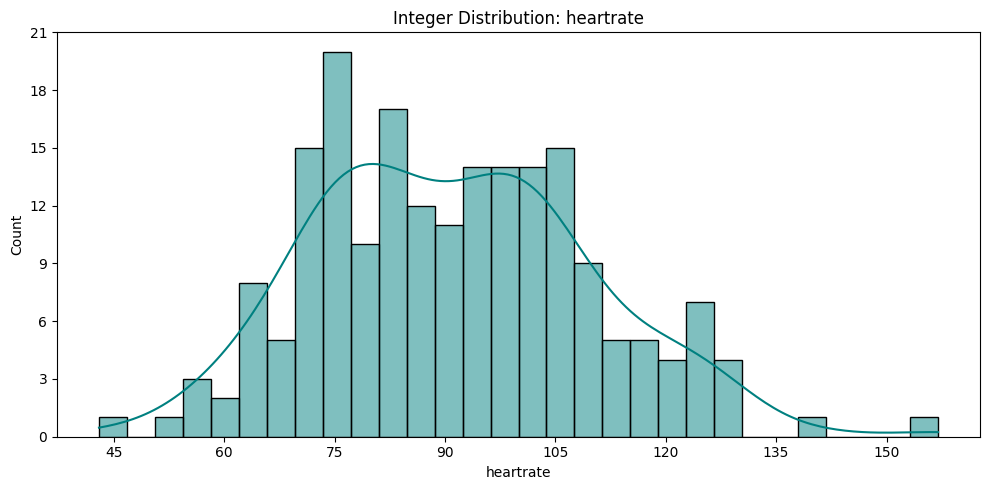

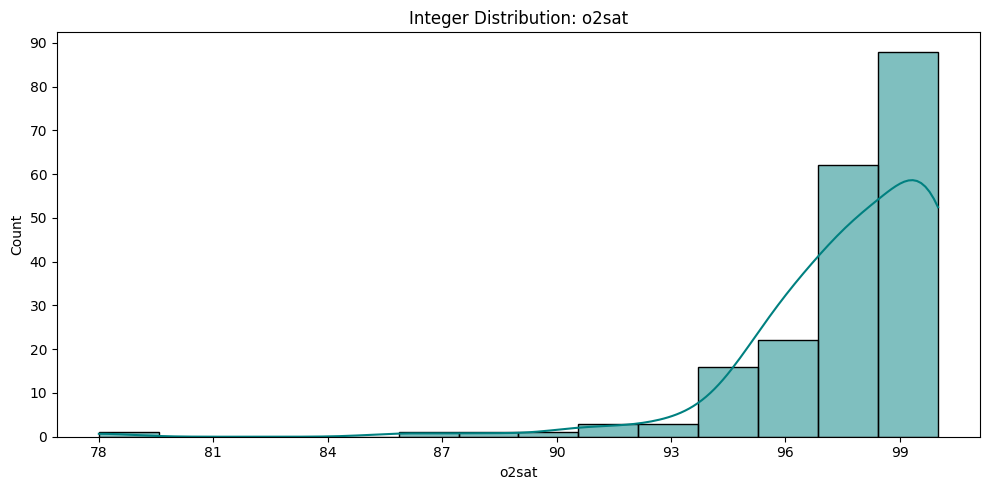

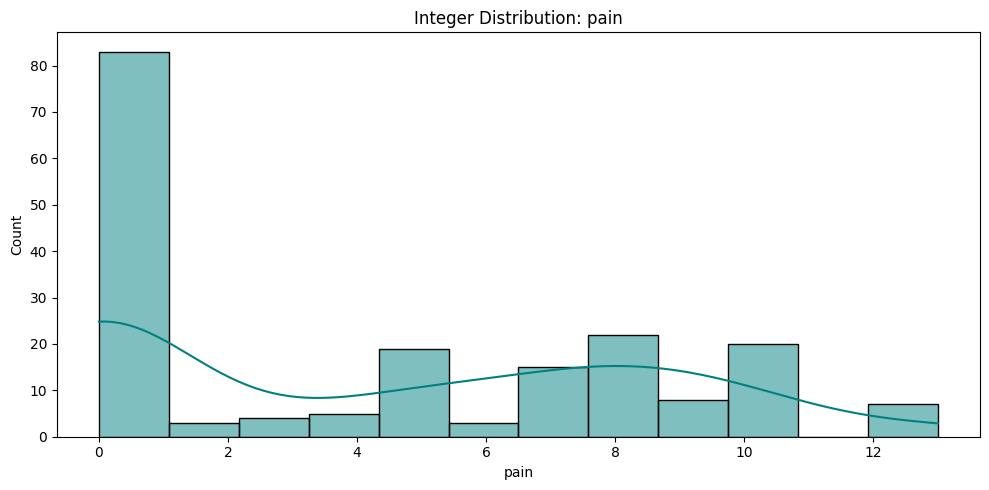

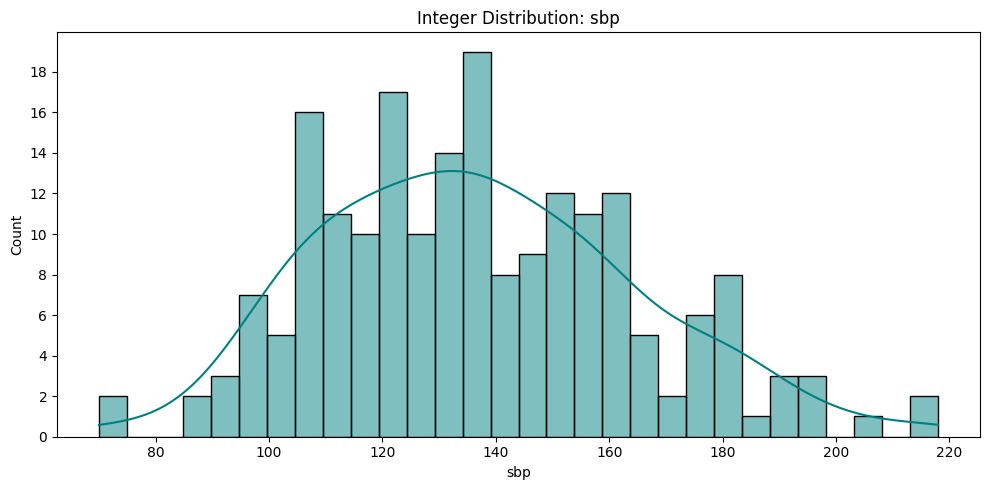

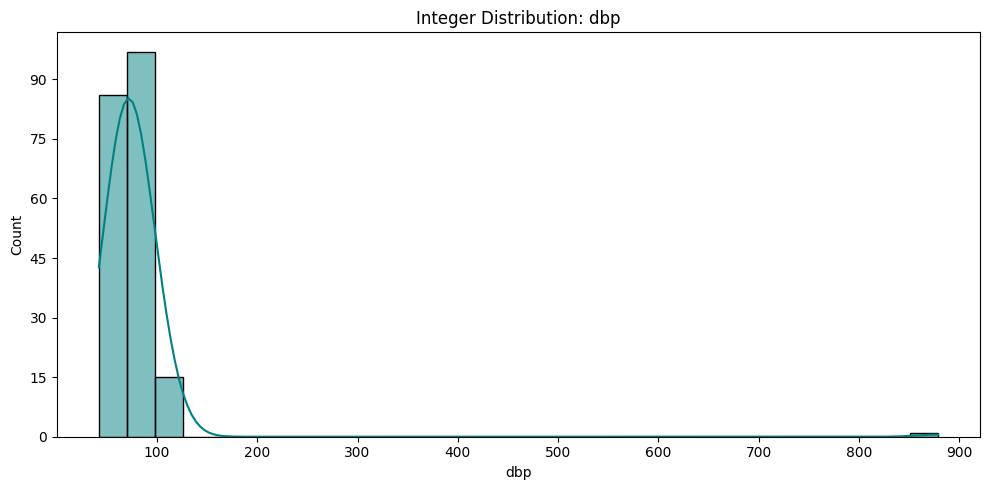

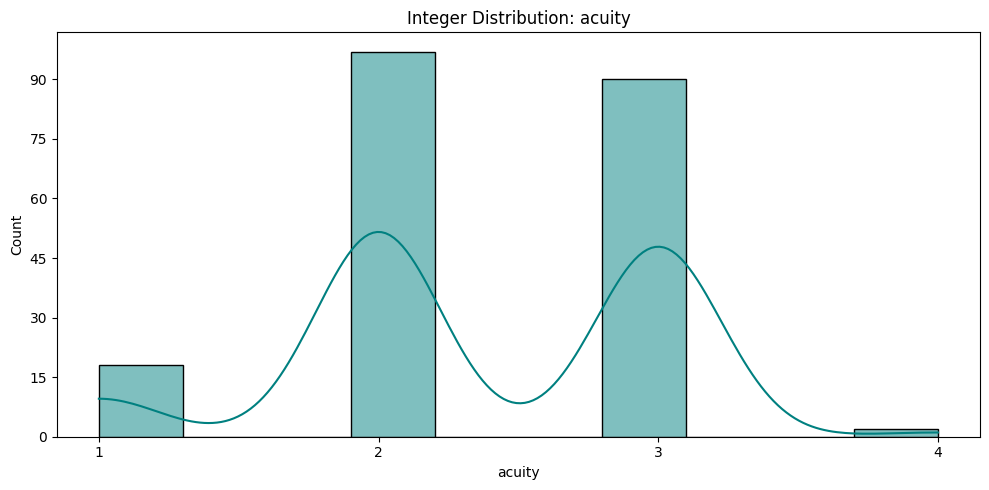

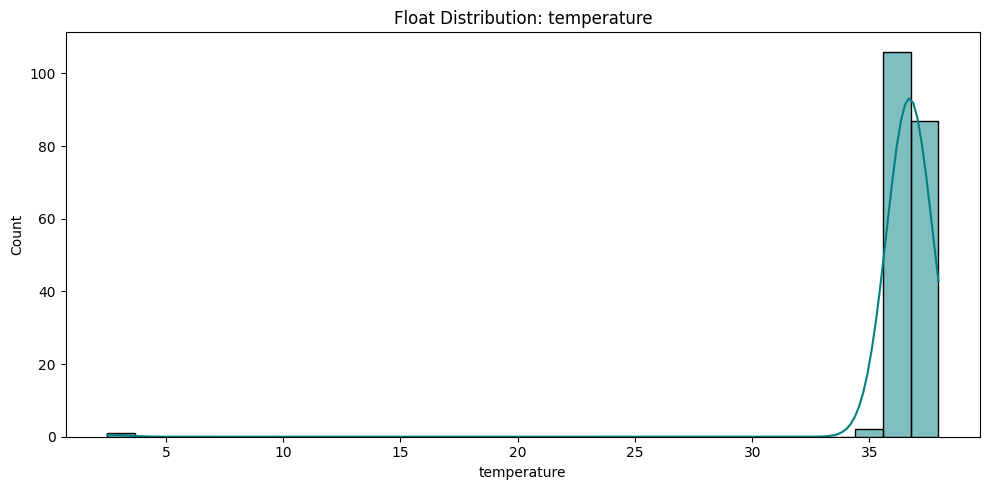

In [8]:
# Plot distributions for each categorical, integer, and float variable
from matplotlib.ticker import MaxNLocator

target_cols = target_column if "target_column" in globals() else []

categorical_cols = [col for col in categorical_columns if col in df.columns]
integer_cols = [col for col in (int_columns + target_cols) if col in df.columns]
float_cols = [col for col in continuous_columns if col in df.columns]

print("Categorical columns:", categorical_cols)
print("Integer columns:", integer_cols)
print("Float columns:", float_cols)

def plot_categorical_distributions(dataframe, columns):
    for col in columns:
        plt.figure(figsize=(10, 5))
        counts = dataframe[col].astype("string").fillna("<NA>").value_counts()
        sns.barplot(x=counts.index, y=counts.values, color="steelblue")
        plt.title(f"Categorical Distribution: {col}")
        plt.xlabel(col)
        plt.ylabel("Count")
        plt.xticks(rotation=45, ha="right")
        plt.tight_layout()
        plt.show()

def plot_numeric_distributions(dataframe, columns, label):
    for col in columns:
        plt.figure(figsize=(10, 5))
        series = pd.to_numeric(dataframe[col], errors="coerce").dropna()
        if series.empty:
            plt.close()
            print(f"Skipped {col}: no valid numeric values.")
            continue

        bins = min(30, max(10, series.nunique()))
        sns.histplot(series, bins=bins, kde=True, color="teal")
        plt.title(f"{label} Distribution: {col}")
        plt.xlabel(col)
        plt.ylabel("Count")

        if label == "Integer":
            ax = plt.gca()
            ax.xaxis.set_major_locator(MaxNLocator(integer=True))
            ax.yaxis.set_major_locator(MaxNLocator(integer=True))
            ax.ticklabel_format(style="plain", axis="x", useOffset=False)

        plt.tight_layout()
        plt.show()

plot_categorical_distributions(df, categorical_cols)
plot_numeric_distributions(df, integer_cols, "Integer")
plot_numeric_distributions(df, float_cols, "Float")

## Missing Data Matrix

TODO 
- [ ] decidir se imputa ou drop
- [ ] se imputa, como?

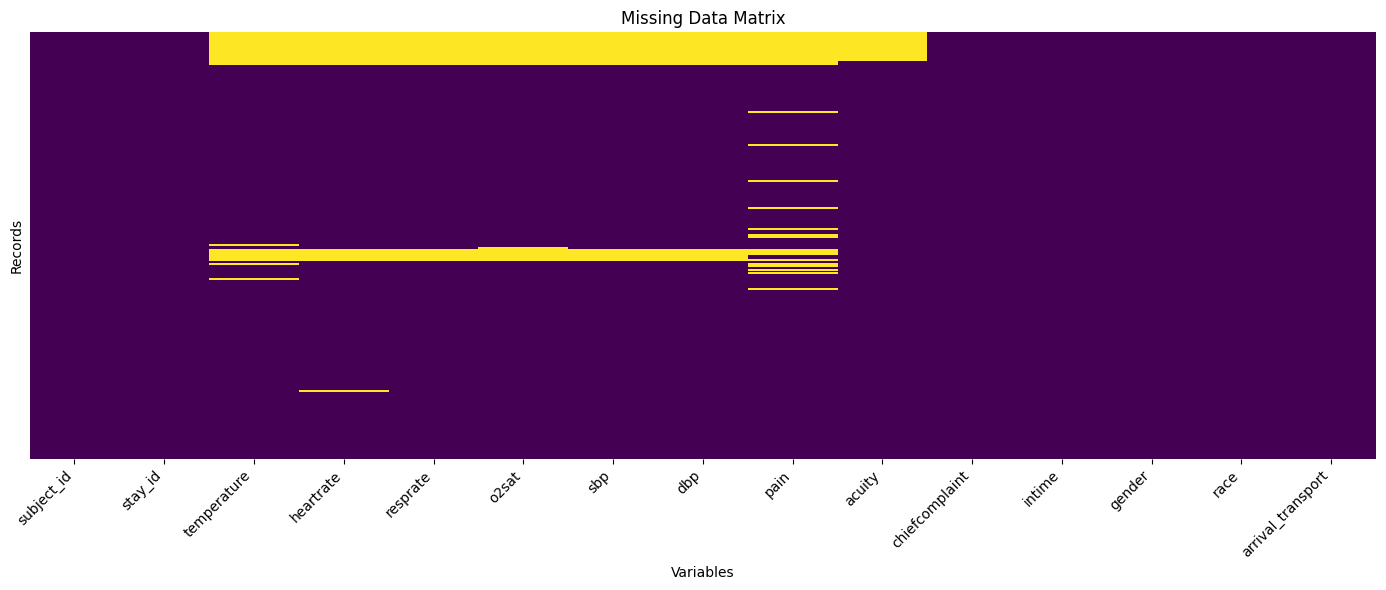

Missing values by column (%):
pain                 14.86
temperature          11.71
o2sat                10.81
heartrate            10.81
resprate             10.36
dbp                  10.36
sbp                  10.36
acuity                6.76
stay_id               0.00
subject_id            0.00
chiefcomplaint        0.00
intime                0.00
gender                0.00
race                  0.00
arrival_transport     0.00
dtype: float64


In [9]:
# Missing data matrix
missing_matrix = df.isna()

plt.figure(figsize=(14, 6))
sns.heatmap(missing_matrix, cbar=False, yticklabels=False, cmap="viridis")
plt.title("Missing Data Matrix")
plt.xlabel("Variables")
plt.ylabel("Records")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

missing_pct = (missing_matrix.mean() * 100).sort_values(ascending=False)
print("Missing values by column (%):")
print(missing_pct.round(2))

if (missing_pct == 0).all():
    print("\nNo missing values detected.")

## Correlation Matrix

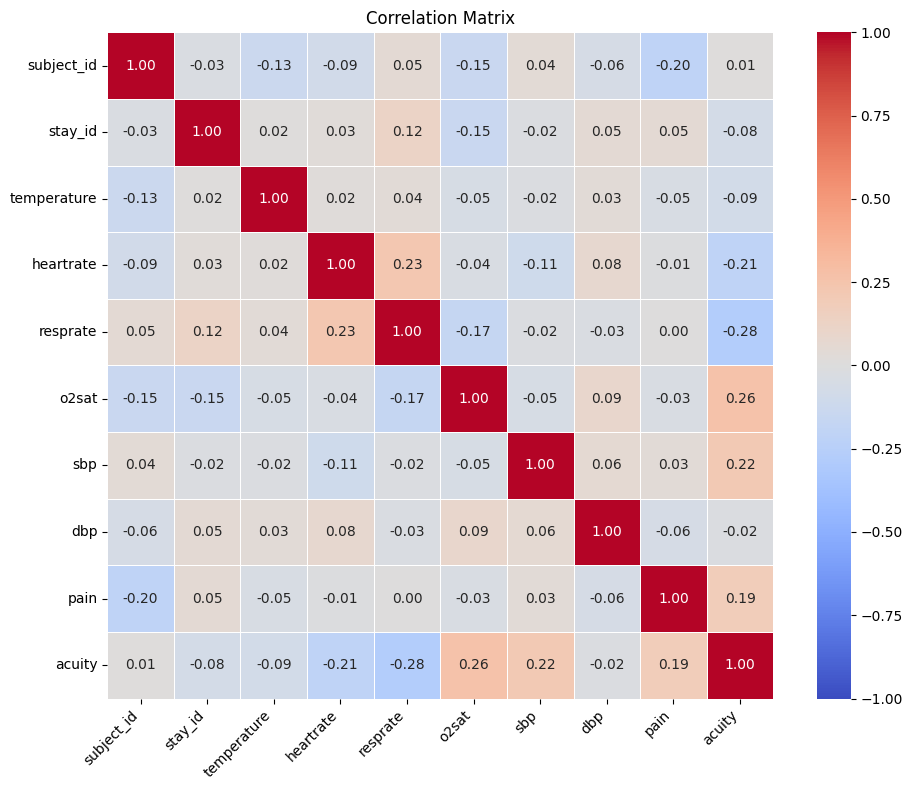

In [10]:
# Correlation matrix (numeric variables only)
numeric_df = df.select_dtypes(include=["number"]).copy()

if numeric_df.shape[1] < 2:
    print("Not enough numeric columns to build a correlation matrix.")
else:
    corr_matrix = numeric_df.corr()

    plt.figure(figsize=(10, 8))
    sns.heatmap(
        corr_matrix,
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        vmin=-1,
        vmax=1,
        linewidths=0.5,
        square=True,
    )
    plt.title("Correlation Matrix")
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

## KMeans Clustering (k=5)

Features used for clustering: ['temperature', 'resprate', 'heartrate', 'o2sat', 'pain', 'sbp', 'dbp']

Cluster counts:
kmeans_5
0     31
1     83
2    106
3      1
4      1
Name: count, dtype: Int64


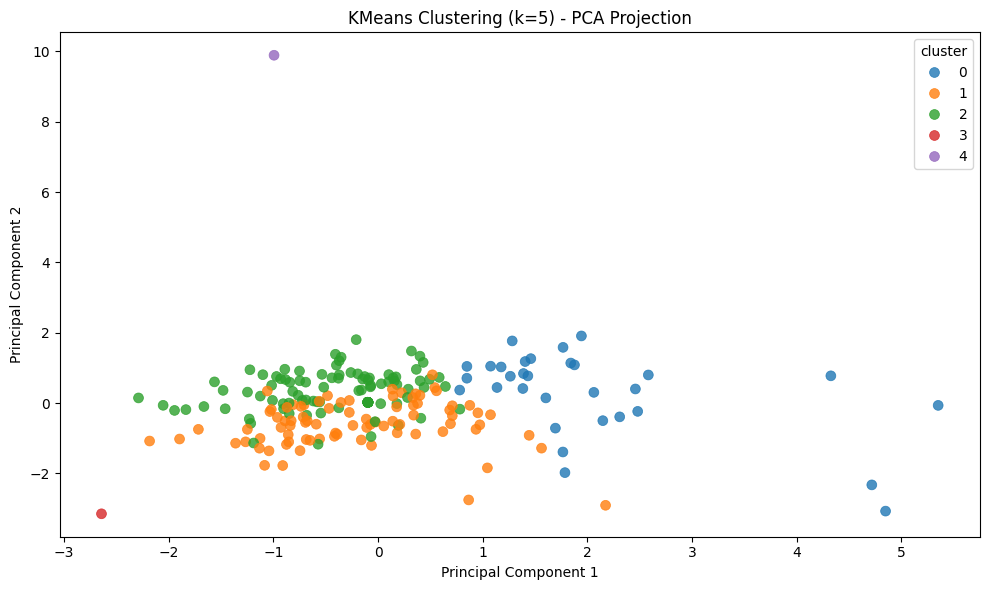

In [11]:
# KMeans with 5 clusters using numeric clinical variables


cluster_features = [
    col for col in (continuous_columns + int_columns)
    if col in df.columns
]

X = df[cluster_features].copy()

# Impute missing values and scale features
imputer = SimpleImputer(strategy="median")
X_imputed = imputer.fit_transform(X)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

# Train KMeans
kmeans = KMeans(n_clusters=5, random_state=SEED, n_init=20)
clusters = kmeans.fit_predict(X_scaled)

# Save cluster labels
df["kmeans_5"] = pd.Series(clusters, index=df.index).astype("Int64")

print("Features used for clustering:", cluster_features)
print("\nCluster counts:")
print(df["kmeans_5"].value_counts().sort_index())

# 2D visualization using PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plot_df = pd.DataFrame(
    {
        "PC1": X_pca[:, 0],
        "PC2": X_pca[:, 1],
        "cluster": clusters,
    }
)

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=plot_df,
    x="PC1",
    y="PC2",
    hue="cluster",
    palette="tab10",
    alpha=0.8,
    s=50,
    edgecolor=None,
    legend="full",
)
plt.title("KMeans Clustering (k=5) - PCA Projection")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.tight_layout()
plt.show()

In [12]:
# PCA diagnostics for interpretation
explained_ratio = pca.explained_variance_ratio_
cumulative_ratio = explained_ratio.cumsum()

print("Explained variance ratio:")
for i, ratio in enumerate(explained_ratio, start=1):
    print(f"PC{i}: {ratio:.4f}")

print(f"\nCumulative explained variance (PC1+PC2): {cumulative_ratio[1]:.4f}")

loadings = pd.DataFrame(
    pca.components_.T,
    index=cluster_features,
    columns=["PC1", "PC2"],
)

print("\nPCA loadings:")
print(loadings.round(4))

print("\nTop contributors to PC1 (absolute loading):")
print(loadings["PC1"].abs().sort_values(ascending=False).head(5).round(4))

print("\nTop contributors to PC2 (absolute loading):")
print(loadings["PC2"].abs().sort_values(ascending=False).head(5).round(4))

centers_pca = pca.transform(kmeans.cluster_centers_)
centers_pca_df = pd.DataFrame(centers_pca, columns=["PC1", "PC2"])
centers_pca_df.index.name = "cluster"
print("\nCluster centers projected on PCA space:")
print(centers_pca_df.round(3))

Explained variance ratio:
PC1: 0.1895
PC2: 0.1638

Cumulative explained variance (PC1+PC2): 0.3534

PCA loadings:
                PC1     PC2
temperature  0.1778  0.1698
resprate     0.6553 -0.0796
heartrate    0.5798  0.3157
o2sat       -0.4018  0.4887
pain        -0.0272 -0.4606
sbp         -0.1963 -0.2532
dbp         -0.0455  0.5917

Top contributors to PC1 (absolute loading):
resprate       0.6553
heartrate      0.5798
o2sat          0.4018
sbp            0.1963
temperature    0.1778
Name: PC1, dtype: float64

Top contributors to PC2 (absolute loading):
dbp          0.5917
o2sat        0.4887
pain         0.4606
heartrate    0.3157
sbp          0.2532
Name: PC2, dtype: float64

Cluster centers projected on PCA space:
           PC1    PC2
cluster              
0        2.034  0.294
1       -0.208 -0.583
2       -0.398  0.307
3       -2.642 -3.147
4       -0.994  9.887


Correlation with acuity (coefficient, p-value):
PC1 vs acuity | Pearson r=-0.3709, p=3.7731e-08 | Spearman rho=-0.3113, p=4.9856e-06
PC2 vs acuity | Pearson r=-0.0715, p=3.0563e-01 | Spearman rho=-0.1017, p=1.4468e-01


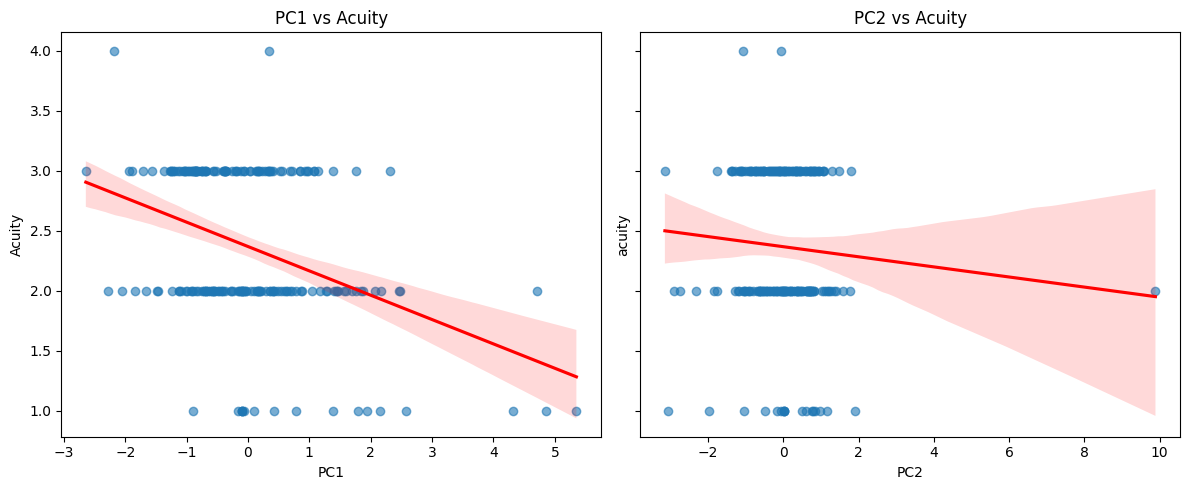

In [13]:
# Correlation between PCA components and acuity (with p-values)

pca_acuity_df = plot_df.copy()
pca_acuity_df["acuity"] = pd.to_numeric(df["acuity"], errors="coerce").values
pca_acuity_df = pca_acuity_df.dropna(subset=["PC1", "PC2", "acuity"])

pearson_pc1_r, pearson_pc1_p = pearsonr(pca_acuity_df["PC1"], pca_acuity_df["acuity"])
pearson_pc2_r, pearson_pc2_p = pearsonr(pca_acuity_df["PC2"], pca_acuity_df["acuity"])
spearman_pc1_r, spearman_pc1_p = spearmanr(pca_acuity_df["PC1"], pca_acuity_df["acuity"])
spearman_pc2_r, spearman_pc2_p = spearmanr(pca_acuity_df["PC2"], pca_acuity_df["acuity"])

print("Correlation with acuity (coefficient, p-value):")
print(
    f"PC1 vs acuity | Pearson r={pearson_pc1_r:.4f}, p={pearson_pc1_p:.4e} "
    f"| Spearman rho={spearman_pc1_r:.4f}, p={spearman_pc1_p:.4e}"
)
print(
    f"PC2 vs acuity | Pearson r={pearson_pc2_r:.4f}, p={pearson_pc2_p:.4e} "
    f"| Spearman rho={spearman_pc2_r:.4f}, p={spearman_pc2_p:.4e}"
)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
sns.regplot(
    data=pca_acuity_df,
    x="PC1",
    y="acuity",
    scatter_kws={"alpha": 0.6},
    line_kws={"color": "red"},
    ax=axes[0],
)
axes[0].set_title("PC1 vs Acuity")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("Acuity")

sns.regplot(
    data=pca_acuity_df,
    x="PC2",
    y="acuity",
    scatter_kws={"alpha": 0.6},
    line_kws={"color": "red"},
    ax=axes[1],
)
axes[1].set_title("PC2 vs Acuity")
axes[1].set_xlabel("PC2")

plt.tight_layout()
plt.show()

PC1 tem associação moderada estatisticamente significativa com acuity.
PC2 não mostrou associação significativa.